# **Question 5**
You can imagine when a protein binds to DNA, then that region will be protected by nucleases (a type of enzyme that cleaves DNA). If you are to plot the protected fragments at protein binding sites, it will take a V-form. Your goal is to show this V-formation using the input data.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


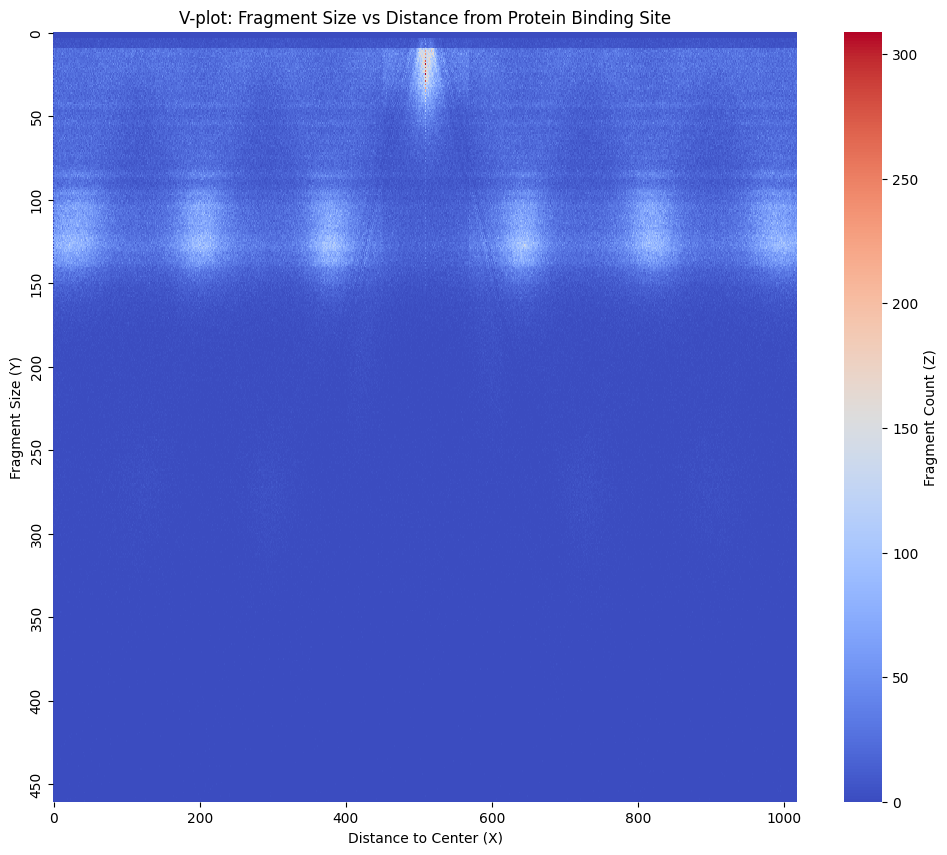

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gzip
from collections import Counter

# Step 1: Load the data
data = []
file_path = '/content/drive/MyDrive/mapped.bed.gz'

with gzip.open(file_path, 'rt') as f:  # 'rt' means read text mode
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 11:
            continue

        c1 = (int(parts[2]) + int(parts[3])) / 2
        c2 = (int(parts[8]) + int(parts[9])) / 2

        x = int(c2 - c1)
        y = int(parts[9]) - int(parts[8])

        data.append((x, y))

# Step 2: Count how many times each (X, Y) occurs
counter = Counter(data)

# Step 3: Prepare 2D grid
# Define X and Y ranges
x_vals = [x for x, y in counter.keys()]
y_vals = [y for x, y in counter.keys()]

x_min, x_max = min(x_vals), max(x_vals)
y_min, y_max = min(y_vals), max(y_vals)

# Build 2D array
heatmap = np.zeros((y_max - y_min + 1, x_max - x_min + 1))

for (x, y), count in counter.items():
    heatmap[y - y_min, x - x_min] = count

# Step 4: Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap, cmap="coolwarm",
            xticklabels=200, yticklabels=50,
            cbar_kws={'label': 'Fragment Count (Z)'})
plt.title("V-plot: Fragment Size vs Distance from Protein Binding Site")
plt.xlabel("Distance to Center (X)")
plt.ylabel("Fragment Size (Y)")
plt.show()
